In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import os
import numpy as np
def load_results(area, methods, log_path):
    all_maes = []
    all_mses = []
    for method in methods:
        path = os.path.join(log_path, method)
        subdir = os.listdir(path)
        subdir = [x for x in subdir if x.endswith('.log')]
        index = [int(x[-5]) for x in subdir]
        subdir = [subdir[i] for i in np.argsort(index)]
        mae = []
        mse = []
        for i in range(9):
            with open(os.path.join(path, subdir[i]), 'rb') as f:
                lines = f.readlines()
                mae.append(float(lines[1][42:47]))
                mse.append(float(lines[1][-7:-1]))
        all_maes.append(mae)
        all_mses.append(mse)
    return np.array(all_maes), np.array(all_mses)

In [3]:
def plot_radar_chart(data, methods, title, metrics):
    N = len(metrics)
    theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
    theta = np.concatenate([theta, [theta[0]]])
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={"projection": "polar"})
    
    ax.set_title(title, y=-0.1, fontsize=34)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(90)
    
    ax.spines["polar"].set_zorder(1)
    ax.spines["polar"].set_color("lightgrey")
    
    # color_palette = ["#A51C36", "#7ABBDB",  "#84BA42", "#682487", "#D4562E", "#4485C7","#DBB428", "#6F6F6F", "#4DB748"]
    color_palette = ["#FF0000", "#8C564B",  "#2CA02C", "#FFCC00", "#1F77B4", "#9467BD","#FF7F0E", "#E377C2", "#330000"]

    

    for i in range(data.shape[0]):
        values = data[i]
        values = np.concatenate([values, values[0][np.newaxis]], 0)
        ax.plot(theta, values, linewidth=4, linestyle="solid", label=methods[i], marker='o', markersize=10,color=color_palette[i%len(color_palette)])
        ax.fill(theta, values, alpha=0.05, color=color_palette[i % len(color_palette)])
        
    
    plt.yticks([0.5, 0.2, 0], color="black", size=24)
    plt.xticks(theta[:-1], metrics, color="black", size=32)
    # plt.yscale("log")
    ax.set_yscale("log")
    

    ax.yaxis.set_inverted(True)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    
    return fig

PRE

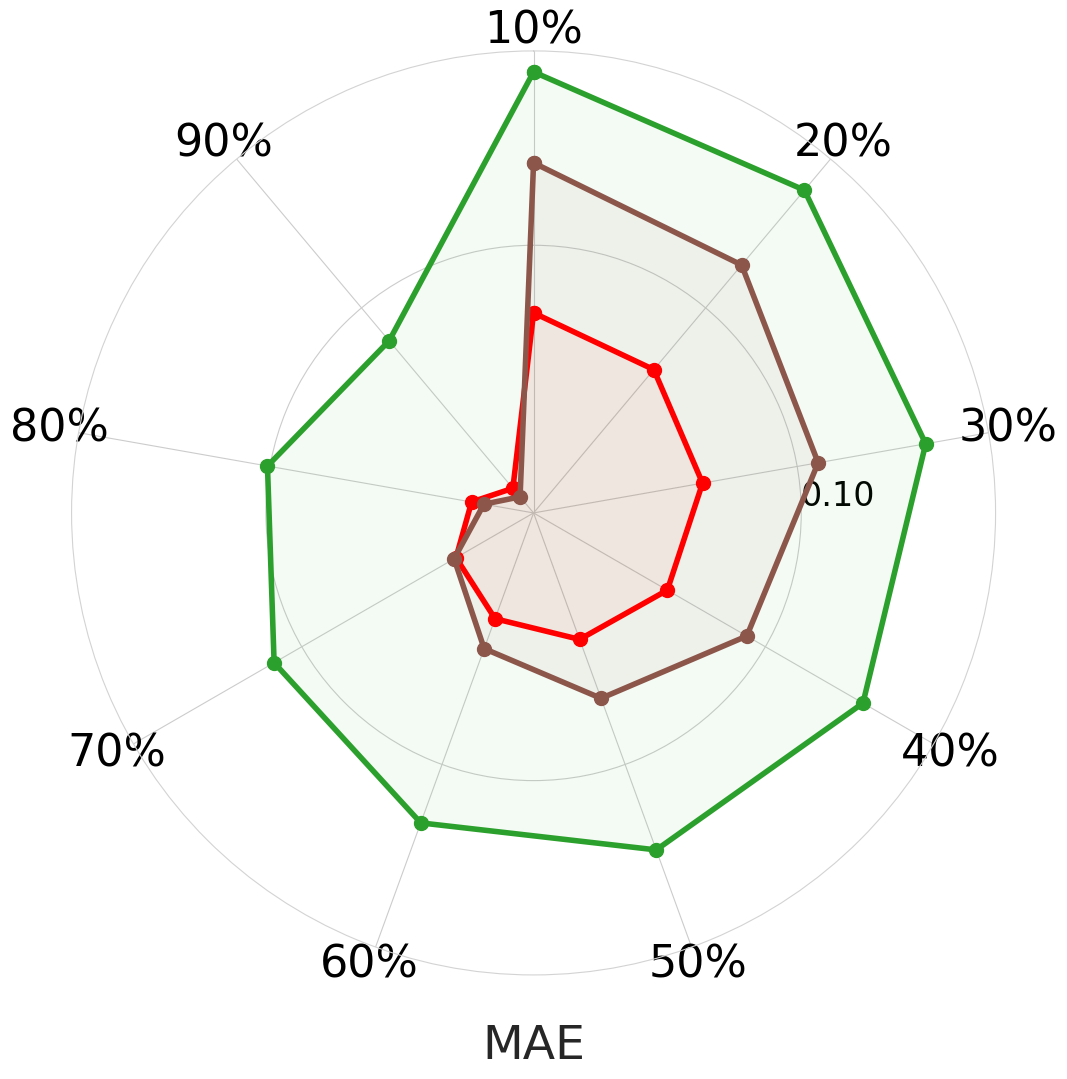

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests
sns.set_style("white")

mae, mse = load_results("PRE",["DINEOF","DINEOF_per_timestep"], "./log/imputation/46/PRE")
methods = ["STIMP", "DINEOF", "DINEOF_per_timestep"]
metrics = ["10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%"]
mse = np.concatenate([mse, np.array([0.0029, 0.0038, 0.0051, 0.0068, 0.0091, 0.0127, 0.0174, 0.0233, 0.0376])[np.newaxis,:]], 0)
mae = np.concatenate([mae, np.array([0.0310, 0.0354, 0.0414, 0.0467, 0.0541, 0.0657, 0.0806, 0.0983,0.1337])[np.newaxis,:]],0)

# Plot 
fig = plot_radar_chart(mae, methods, title="MAE", metrics=metrics)
plt.show()

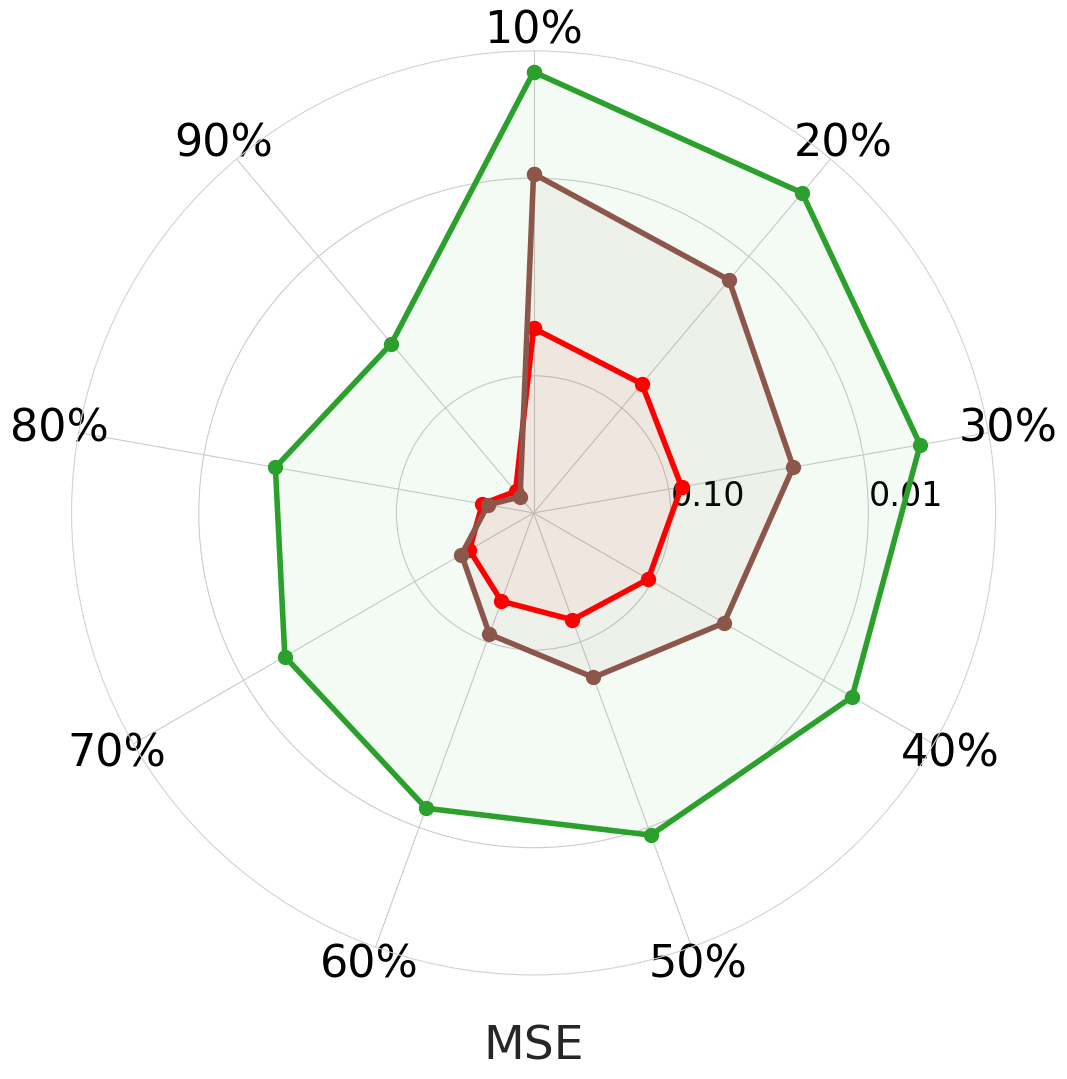

In [18]:
fig = plot_radar_chart(mse, methods, title="MSE", metrics=metrics)
plt.show()